# Notebook 04: XGBoost Challenger Model + SHAP Explainability
**BFSI Credit Risk Scorecard — Canadian Banking Edition**  
Challenger: XGBoost + Optuna HPO · SHAP adverse action codes · OSFI E-23

## Overview
The XGBoost challenger model serves two purposes:
1. **Benchmarking**: Validates whether the LR champion captures all signal
2. **Explainability**: SHAP values provide OSFI-compliant adverse action codes

**Canadian regulatory note:** OSFI E-23 requires that challenger models
be run in production shadow-mode for minimum 6 months before promotion to champion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
import joblib
import sys
sys.path.insert(0, "../src")

from model_training import train_xgboost_challenger, SHAPExplainer, compare_champion_challenger
from model_validation import compute_discrimination_metrics, plot_roc_curve, plot_ks_curve
import yaml, warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
X_train_woe = pd.read_csv("../data/processed/X_train_woe.csv")
X_val_woe   = pd.read_csv("../data/processed/X_val_woe.csv")
X_test_woe  = pd.read_csv("../data/processed/X_test_woe.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val   = pd.read_csv("../data/processed/y_val.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()
scorecard = joblib.load("../models/scorecard_model.pkl")

with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

## 1. Train XGBoost Challenger

In [3]:
print("Training XGBoost challenger (Optuna HPO, 30 trials)...")
challenger = train_xgboost_challenger(
    X_train_woe, y_train, X_val_woe, y_val, config, n_trials=30
)
print(f"\nBest params: {challenger['best_params']}")
print(f"Val AUC: {challenger['val_auc']:.4f}")

xgb_pd_test = challenger["calibrated_model"].predict_proba(X_test_woe)[:, 1]
lr_pd_test  = scorecard.predict_proba(X_test_woe)

xgb_metrics = compute_discrimination_metrics(y_test.values, xgb_pd_test)
lr_metrics  = compute_discrimination_metrics(y_test.values, lr_pd_test)

print(f"\nXGBoost Test — AUC: {xgb_metrics['AUC_ROC']:.4f} | Gini: {xgb_metrics['Gini']:.4f} | KS: {xgb_metrics['KS_Statistic']:.4f}")
print(f"LR Test      — AUC: {lr_metrics['AUC_ROC']:.4f} | Gini: {lr_metrics['Gini']:.4f} | KS: {lr_metrics['KS_Statistic']:.4f}")

Training XGBoost challenger (Optuna HPO, 30 trials)...

Best params: {'n_estimators': 594, 'max_depth': 4, 'learning_rate': 0.022349076400608563, 'subsample': 0.8355297139514993, 'colsample_bytree': 0.7739733582996609, 'min_child_weight': 9, 'scale_pos_weight': 4.020457280385078, 'eval_metric': 'auc', 'random_state': 42, 'tree_method': 'hist'}
Val AUC: 0.7242

XGBoost Test — AUC: 0.6609 | Gini: 0.3219 | KS: 0.2671
LR Test      — AUC: 0.6681 | Gini: 0.3363 | KS: 0.2799


## 2. Champion vs Challenger Comparison


Champion-Challenger Comparison:
      Metric  Champion (LR Scorecard)  Challenger (XGBoost)  Difference               Verdict
     AUC-ROC                   0.6681                0.6609     -0.0072          = Comparable
        Gini                   0.3363                0.3219     -0.0144   ✓ Champion Superior
KS Statistic                   0.2799                0.2671     -0.0128   ✓ Champion Superior
 Brier Score                   0.1504                0.1455     -0.0049          = Comparable
 Sensitivity                   0.0000                0.2605      0.2605 ✓ Challenger Superior
 Specificity                   1.0000                0.9434     -0.0566   ✓ Champion Superior


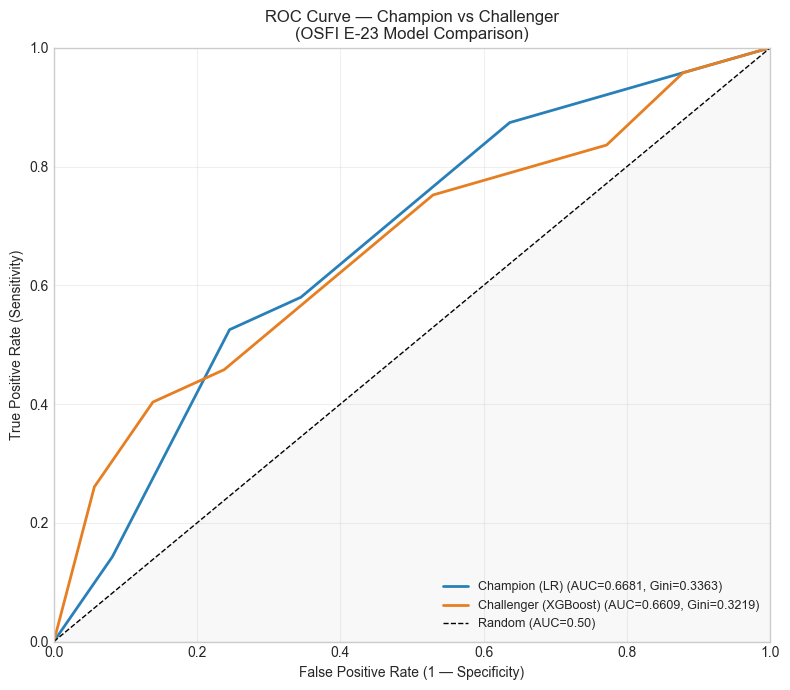

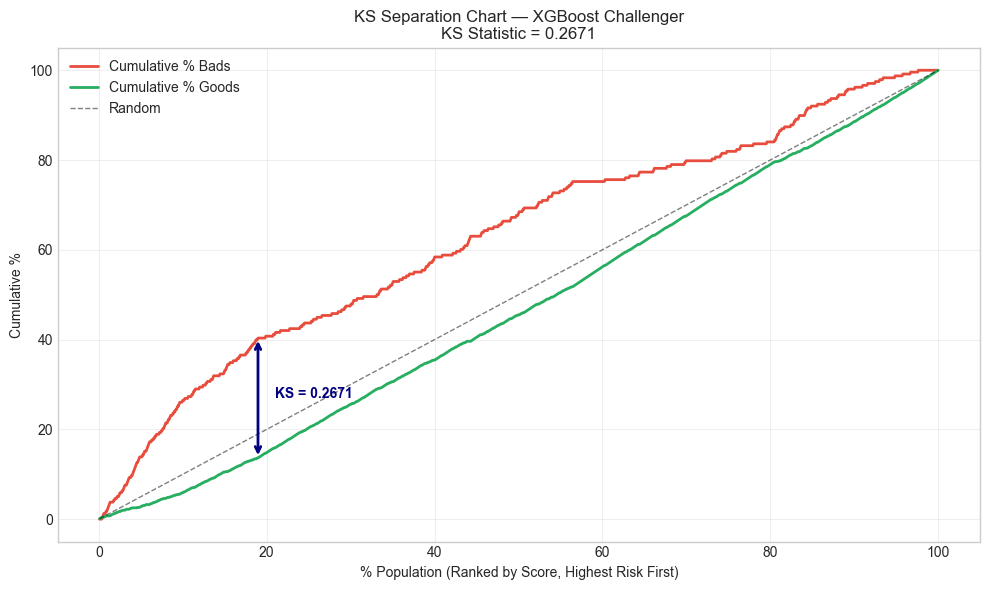

In [4]:
comparison = compare_champion_challenger(
    {"calibrated_model": scorecard.calibrated_lr},
    challenger,
    X_test_woe, y_test
)
print("\nChampion-Challenger Comparison:")
print(comparison.to_string(index=False))

# ROC comparison
fig = plot_roc_curve(
    {"Champion (LR)": y_test.values, "Challenger (XGBoost)": y_test.values},
    {"Champion (LR)": lr_pd_test,    "Challenger (XGBoost)": xgb_pd_test},
    title="ROC Curve — Champion vs Challenger\n(OSFI E-23 Model Comparison)"
)
plt.savefig("../reports/output/04_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# KS chart for XGBoost
fig = plot_ks_curve(y_test.values, xgb_pd_test, model_name="XGBoost Challenger")
plt.savefig("../reports/output/04_ks_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. SHAP Feature Importance

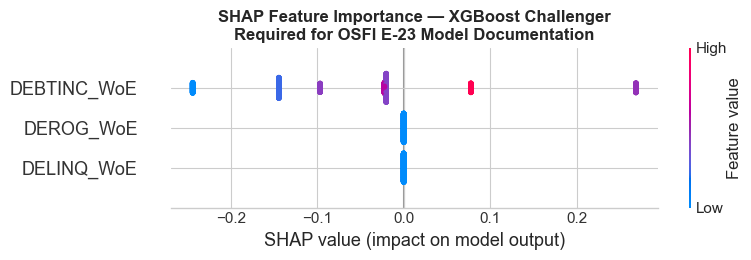

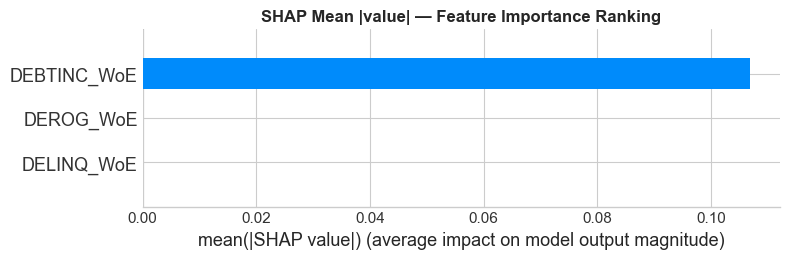

In [5]:
explainer = SHAPExplainer(challenger["model"], X_train_woe)
shap_values = explainer.compute_shap_values(X_test_woe)

# Summary (beeswarm) plot
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_woe, max_display=15, show=False, plot_type="dot")
plt.title("SHAP Feature Importance — XGBoost Challenger\n"
          "Required for OSFI E-23 Model Documentation", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/04_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar importance
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_woe, max_display=15, show=False, plot_type="bar")
plt.title("SHAP Mean |value| — Feature Importance Ranking", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/04_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Individual Prediction Explanation


High-risk applicant (idx 12):
  PD: 0.5726
  Actual outcome: 0
  [INCREASES RISK] DEBTINC_WoE: SHAP=0.2687
  [DECREASES RISK] DELINQ_WoE: SHAP=0.0000
  [DECREASES RISK] DEROG_WoE: SHAP=0.0000


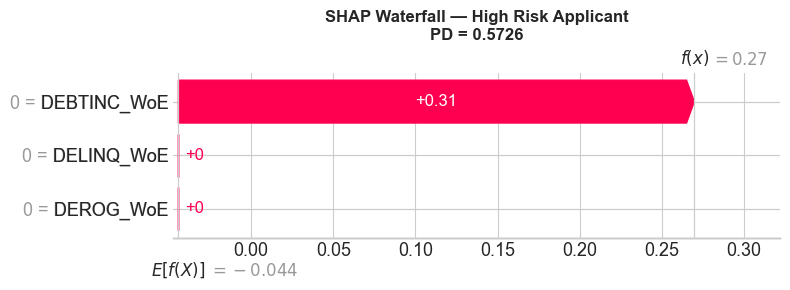

In [6]:
# High-risk applicant
high_risk_idx  = np.argmax(xgb_pd_test)
low_risk_idx   = np.argmin(xgb_pd_test)

print(f"\nHigh-risk applicant (idx {high_risk_idx}):")
print(f"  PD: {xgb_pd_test[high_risk_idx]:.4f}")
print(f"  Actual outcome: {y_test.values[high_risk_idx]}")
reasons = explainer.get_top_reasons(X_test_woe.iloc[[high_risk_idx]])
for r in reasons:
    print(f"  [{r['direction'].upper()}] {r['feature']}: SHAP={r['shap_value']:.4f}")

# Waterfall for one high-risk applicant (fallback to bar chart if waterfall unavailable)
try:
    shap_exp = shap.Explainer(challenger["model"], X_test_woe)
    sv = shap_exp(X_test_woe.iloc[[high_risk_idx]])
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(sv[0], show=False)
    plt.title(f"SHAP Waterfall — High Risk Applicant\nPD = {xgb_pd_test[high_risk_idx]:.4f}",
              fontweight="bold")
    plt.tight_layout()
    plt.savefig("../reports/output/04_shap_waterfall_highrisk.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Waterfall plot: {e}. Using bar chart instead.")
    vals   = shap_values[high_risk_idx]
    feats  = X_test_woe.columns
    order  = np.argsort(np.abs(vals))[::-1][:12]
    colors = ["#dc2626" if v > 0 else "#16a34a" for v in vals[order]]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(order)), vals[order], color=colors, edgecolor="white")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([feats[i] for i in order], fontsize=9)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("SHAP Value (impact on log-odds)")
    ax.set_title(f"SHAP — High Risk Applicant (PD={xgb_pd_test[high_risk_idx]:.4f})",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig("../reports/output/04_shap_waterfall_highrisk.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. SHAP Dependence Plots (Top 2 Features)

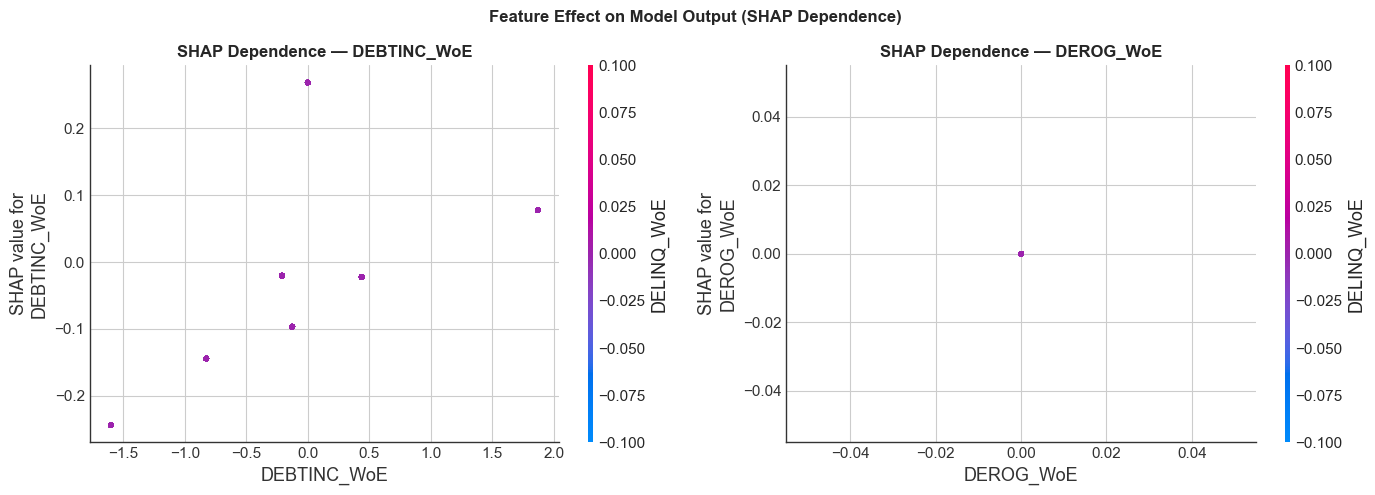

In [7]:
top2_features = [X_test_woe.columns[np.abs(shap_values).mean(axis=0).argsort()[-1]],
                 X_test_woe.columns[np.abs(shap_values).mean(axis=0).argsort()[-2]]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_features):
    shap.dependence_plot(feat, shap_values, X_test_woe, ax=ax, show=False,
                         interaction_index="auto")
    ax.set_title(f"SHAP Dependence — {feat}", fontweight="bold")
plt.suptitle("Feature Effect on Model Output (SHAP Dependence)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/04_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Save Challenger

In [8]:
joblib.dump(challenger["calibrated_model"], "../models/xgb_challenger.pkl")
#challenger["model"].save_model("../models/xgb_raw.json")          #save_model() is NOT available for GradientBoostingClassifier (from scikit-learn). It IS available for XGBoost models (XGBClassifier, Booster from xgboost)
joblib.dump(challenger["model"], "../models/xgb_challenger.pkl")
comparison.to_csv("../data/processed/champion_challenger_comparison.csv", index=False)
print(" Challenger model saved: models/xgb_challenger.pkl")
print(" Comparison table saved: data/processed/champion_challenger_comparison.csv")

 Challenger model saved: models/xgb_challenger.pkl
 Comparison table saved: data/processed/champion_challenger_comparison.csv


In [9]:
print(type(challenger["model"]))

<class 'xgboost.sklearn.XGBClassifier'>


In [10]:
import sklearn
print(sklearn.__version__)

1.4.2
